# An End-to-End AI Harvest Planner for Low-Cost Fruit-Picking Robots Built on a Physics-Consistent World Model

**`05_test.ipynb`**

One tree, taken all the way through, and the pictures that come out of it.

The three notebooks before this one report averages: thirty seeds, eight hundred picks, held-out
splits. Averages are what the numbers rest on and they are the wrong thing to look at when the
question is whether the system actually works. So here a single tree is planned, the plan is
replayed against the physics, and the two are laid side by side — what the model said would
happen, and what happened.

The checks in section 3 are the ones that have caught something at least once in this project.
Each is a line that would have failed at the moment a mistake was made rather than an hour
later: a scene that could not be found because the working directory changed, a policy fed
inputs scaled differently from training, a dataset whose split lived on a different file.

Section 4 writes the images. They go to `runs/report/` as PNG and are meant for the completion
report and the presentation, not for the notebook.


In [1]:
import os, sys, json, time, importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import mujoco
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Default to the folder this notebook sits in, so a clone runs without setup. An absolute
# default only ever pointed at one machine, and an environment variable set in a shell does
# not reach a kernel that was already running.
ROOT = Path(os.environ.get("AIPICK_ROOT") or Path.cwd())
os.environ["AIPICK_ROOT"] = str(ROOT)
SRC, DATA, MODELS = ROOT/"src", ROOT/"data", ROOT/"models"
RUNS = ROOT/"runs"
REPORT = RUNS/"report"; REPORT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SRC))

import environment as E
import physics as A
import planner as PL

TREES_USED = "trees_measured_pose.csv"
E.load(ROOT, trees=TREES_USED, dynamics=True)

spec = importlib.util.spec_from_file_location("gen", SRC/"generate.py")
G = importlib.util.module_from_spec(spec); G.__name__ = "gen"
spec.loader.exec_module(G)

TREES_EVAL = list(range(20, 50))
DEMO = 23                      # the tree 04 kept a pose stream for

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

print(f"root {ROOT}")
print(f"canopy {TREES_USED}: {len(E.T):,} fruit, dynamics {'on' if E.DYN else 'off'}")
print(f"demonstration tree {DEMO}")
print(f"images -> {REPORT}")





root c:\aipick\git
canopy trees_measured_pose.csv: 6,000 fruit, dynamics on
demonstration tree 23
images -> c:\aipick\git\runs\report


## 1. One tree, end to end

Detections in, a plan out. The planning is `src/planner.py` — this notebook calls it and looks at
what comes back, which is the arrangement the whole repository now uses. The plan itself is one
row per pick: which stop, which fruit, what the outcome model expects of it, and the clock.


In [2]:
import planner as PL

info = PL.load(ROOT)
print(f"planner {info['planner']}   policy {info['policy']}   scaling {info['scaling']}")
print(f"  move_secs {info['move_secs'][0]:.3f} / {info['move_secs'][1]:.3f}"
      f"   (training recorded 385.324 / 485.485)")
print(f"configuration: {PL.K_STATIONS} stops + sweep, threshold {PL.THRESHOLD}, "
      f"arm {PL.HALF_X} x {PL.LIFT} m\n")

HALF_X, LIFT = PL.HALF_X, PL.LIFT
THRESHOLD, K_STATIONS = PL.THRESHOLD, PL.K_STATIONS

CASE = PL.tree_case(DEMO)
PLAN = PL.plan_tree(CASE)
S = PLAN.attrs["summary"]
geom, Pp, Cp = CASE["geom"], CASE["POS"], CASE["COV"]
st = E.TreeState(geom)                       # a fresh state for the sections below
STOPS = sorted(PL.stations(CASE)[0], key=lambda r: Pp[r][0])   # the stop indices, in row order

print(f"tree {DEMO}\n")
print(f"  on the tree            {S['on_tree']:>6}")
print(f"  the robot can reach    {S['robot_reach']:>6}")
print(f"  stops                  {S['stops']:>6}"
      f"   ({S['stage1_stops']} from the planner + {S['sweep_stops']} sweep)")
print(f"  in the plan            {S['in_plan']:>6}"
      f"   {S['in_plan']/S['robot_reach']*100:.0f}% of reachable")
print(f"  attempted              {S['attempts']:>6}")
print(f"  expected premium       {S['exp_success']:>6.1f}")
print(f"  expected utility       {S['exp_utility']:>6.1f}")
print(f"  time on the tree       {S['seconds']:>6.0f} s   = {S['seconds']/60:.1f} min")
print(f"  left for a person      {S['left_reachable']:>6}   within reach, not planned\n")
print(PLAN.head(15).to_string(index=False))

PLAN.to_csv(REPORT/f"plan_tree{DEMO}.csv", index=False)
print(f"\nwritten {REPORT/f'plan_tree{DEMO}.csv'}")




c:\python\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


planner station_planner_k20.pt   policy pick_policy.pt   scaling recomputed
  move_secs 385.324 / 485.485   (training recorded 385.324 / 485.485)
configuration: 20 stops + sweep, threshold 0.0, arm 0.2 x 0.6 m

tree 23

  on the tree               120
  the robot can reach        68
  stops                      24   (20 from the planner + 4 sweep)
  in the plan                68   100% of reachable
  attempted                  68
  expected premium         56.1
  expected utility         52.2
  time on the tree         1308 s   = 21.8 min
  left for a person           0   within reach, not planned

 step  stop     x  mast  fruit  height  p_success  exp_utility  secs
    1    21  0.60  4.48    104   4.535     0.9969       0.9961  14.0
    2     6 -0.40  2.23     77   2.259     0.9954       0.9943  46.3
    3     8 -0.30  3.53      8   4.066     0.9951       0.9939  69.3
    4     8 -0.30  3.53     52   3.586     0.9944       0.9930  83.3
    5    19  0.45  2.08     69   2.313     0.9941

## 2. The four layers, on this tree

The plan above is the third layer's output. The other three are underneath it and none of them
show up in a table of stops, so each is asked for its answer on the same tree.

**Layer 1 — what a pick does to its neighbours.** Every planned pick disturbs whatever is
standing next to it, and the settled-pose model says which of those survivors will still be
tilted once the scene comes to rest.

**Layer 2 — ordering inside a cluster.** Exhaustive search over the orders within each cluster,
against what a greedy rate rule would have chosen. This layer is a benchmark rather than a
component, and the numbers below are the reason.

**Layer 3 — planning the tree.** The table above.

**Layer 4 — what the plan is worth.** Expected utility is in grade units, not fruit: a knocked
neighbour costs half a premium fruit, a torn stem costs three tenths. Converting to a shift is
where the business case starts and where the honest caveats live.


In [3]:
from itertools import permutations

# --- 1. settled-pose dynamics ----------------------------------------------------------------
print("1. what each pick does to the fruit beside it\n")
if E.DYN is None:
    print("   the dynamics model is not loaded; E.load(..., dynamics=True) enables it")
    DYN_ROWS = pd.DataFrame()
else:
    st1 = E.TreeState(geom)
    rows1 = []
    for _, r in PLAN.iterrows():
        j = int(np.where(geom.ids == r.fruit)[0][0])
        nb = geom.disturbed_by(j)
        nb = nb[st1.alive[nb] & (nb != j)]
        surv = int(st1.alive[geom.WITHIN[:, j]].sum()) - 1
        if len(nb) and surv >= 2:
            p = E.DYN["model"].predict_proba(
                st1._dyn_rows(nb, j, st1._obs(rows=nb)))[:, 1]
            for k, pk in zip(nb, p):
                rows1.append(dict(step=int(r.step), picked=int(r.fruit),
                                  neighbour=int(geom.ids[k]), survivors=surv,
                                  lean_before=round(float(geom.LEAN0[k]), 2),
                                  p_still_tilted=round(float(pk), 3),
                                  verdict="stays tilted" if pk >= E.DYN_THRESH
                                          else "hangs plumb"))
        st1.remove(j)
    DYN_ROWS = pd.DataFrame(rows1)
    if len(DYN_ROWS):
        print(DYN_ROWS.to_string(index=False))
        n_t = int((DYN_ROWS.p_still_tilted >= E.DYN_THRESH).sum())
        print(f"\n   {len(DYN_ROWS)} neighbours judged, {n_t} predicted to stay tilted")
        print(f"   the model reaches AUC {E.DYN['cv_auc']:.3f} on held-out trees at a "
              f"{E.DYN['base_rate']*100:.0f}% base rate")
        DYN_ROWS.to_csv(REPORT/f"layer1_dynamics_tree{DEMO}.csv", index=False)
    else:
        print("   no pick on this tree left two or more survivors in contact --")
        print("   with one survivor the outcome is decided: nothing holds it, so it hangs plumb")

# --- 2. ordering inside a cluster ------------------------------------------------------------
print("\n\n2. does the order inside a cluster matter here\n")
seen, rows2 = set(), []
for i in range(geom.n):
    if i in seen:
        continue
    grp = sorted(set([int(k) for k in np.where(geom.WITHIN[i])[0]] + [i]))
    if not (2 <= len(grp) <= 4) or any(k in seen for k in grp):
        continue
    seen.update(grp)

    best = -np.inf
    for order in permutations(grp):
        s = E.TreeState(geom); tot = 0.0
        for j in order:
            tot += float(s.probabilities(j) @ E.UTIL_VEC); s.remove(j)
        best = max(best, tot)

    s = E.TreeState(geom); tot, taken = 0.0, []
    for _ in grp:
        u = s.utilities()
        j = max((k for k in grp if k not in taken), key=lambda k: u[k])
        tot += float(s.probabilities(j) @ E.UTIL_VEC); s.remove(j); taken.append(j)
    rows2.append(dict(size=len(grp), fruit=[int(geom.ids[k]) for k in grp],
                      exhaustive=round(best, 4), greedy=round(tot, 4),
                      gap=round(best - tot, 4)))

CL = pd.DataFrame(rows2)
if len(CL):
    print(CL.groupby("size").agg(clusters=("gap", "size"),
                                 matched=("gap", lambda s: (s < 1e-9).mean()),
                                 mean_gap=("gap", "mean"),
                                 worst=("gap", "max")).round(4).to_string())
    print(f"\n   {len(CL)} clusters, greedy reaches the optimum on "
          f"{(CL.gap < 1e-9).mean()*100:.0f}% of them, mean gap {CL.gap.mean():.4f}")
    print("   Getting the order wrong costs very little, which is why this layer is measured")
    print("   and then left out of the chain.")
    CL.to_csv(REPORT/f"layer2_clusters_tree{DEMO}.csv", index=False)
else:
    print("   no clusters of two to four on this tree")

# --- 3. the tree plan ------------------------------------------------------------------------
print("\n\n3. the plan, from the table above\n")
print(f"   {len(STOPS)} stops, {len(PLAN)} picks, "
      f"{int((st.alive & Cp.any(axis=0)).sum())} left for a person, "
      f"{PLAN.secs.iloc[-1]:.0f} s")

# --- 4. what the plan is worth ---------------------------------------------------------------
print("\n\n4. what the plan is worth\n")
p_succ = PLAN.p_success.to_numpy(float)
exp_u = PLAN.exp_utility.to_numpy(float)
secs = float(PLAN.secs.iloc[-1])
per_fruit = secs/len(PLAN)
reach_n = int(Cp.any(axis=0).sum())

print(f"   expected premium fruit      {p_succ.sum():8.2f}   of {len(PLAN)} attempts")
print(f"   expected utility            {exp_u.sum():8.2f}   grade units, not fruit")
print(f"   cost of what it damages     {p_succ.sum() - exp_u.sum():8.2f}   "
      f"knocked neighbours and torn stems")
print(f"   time on this tree           {secs:8.0f} s   {per_fruit:.1f} s per attempt")
print(f"\n   of {geom.n} fruit on the tree, {reach_n} are reachable from the candidate grid,")
print(f"   the robot plans {len(PLAN)} ({len(PLAN)/geom.n*100:.0f}% of the tree) and leaves the rest.")
print(f"   That is a division of labour, not a replacement: the selection threshold is {THRESHOLD},")
print(f"   so fruit the model is unsure about are deliberately passed over.")

shift_s = 3600.0
trees_per_shift = shift_s/(secs + E.TREE_SPACING/E.TRAVEL)
print(f"\n   at this rate one hour covers {trees_per_shift:.1f} trees and about "
      f"{trees_per_shift*p_succ.sum():.0f} premium fruit")
print(f"   The evaluated figure over thirty seeds is 238.0 per shift; this single tree is")
print(f"   shown to make the arithmetic visible, not to replace that measurement.")
print(f"\n   Caveat worth carrying: the pick cycle is fixed at {E.PICK_SECONDS:.0f} s and is not")
print(f"   measured from a machine. Halving it is worth more than every planning lever")
print(f"   combined, so it is the number to interrogate before any of the above.")

json.dump(dict(tree=DEMO, stops=len(STOPS), planned=int(len(PLAN)),
               reachable=reach_n, on_tree=int(geom.n),
               left_for_a_person=int((st.alive & Cp.any(axis=0)).sum()),
               expected_premium=float(p_succ.sum()), expected_utility=float(exp_u.sum()),
               seconds=secs, seconds_per_attempt=float(per_fruit),
               neighbours_judged=int(len(DYN_ROWS)),
               clusters=int(len(CL)),
               cluster_mean_gap=float(CL.gap.mean()) if len(CL) else None),
          open(REPORT/f"layers_tree{DEMO}.json", "w"), indent=1)
print(f"\nwritten {REPORT/f'layers_tree{DEMO}.json'}")




1. what each pick does to the fruit beside it

 step  picked  neighbour  survivors  lean_before  p_still_tilted      verdict
    2      77          2          7         0.00           0.006  hangs plumb
    2      77         62          7         0.00           0.001  hangs plumb
    2      77         64          7         0.03           0.005  hangs plumb
    2      77         76          7         0.00           0.010  hangs plumb
    2      77         89          7         0.00           0.013  hangs plumb
    2      77         90          7         0.02           0.002  hangs plumb
    2      77         91          7         0.00           0.011  hangs plumb
    2      77         94          7        22.23           0.950 stays tilted
    5      69          6          4         0.00           0.001  hangs plumb
    5      69          7          4         0.01           0.005  hangs plumb
    5      69         28          4         0.18           0.015  hangs plumb
    5      69    

### Figures and a table for the manuscript

Layers 1 to 3 go in as still images -- one figure each, sized for a column and written as PNG.
The animations are separate work and are not built here; what a reader needs on the page is a
frame they can look at.

Layer 4 is a table rather than a picture, because every line of it is a number someone will
want to quote. It is written three ways: Markdown to paste into a draft, LaTeX for a journal
template, and CSV for a spreadsheet.


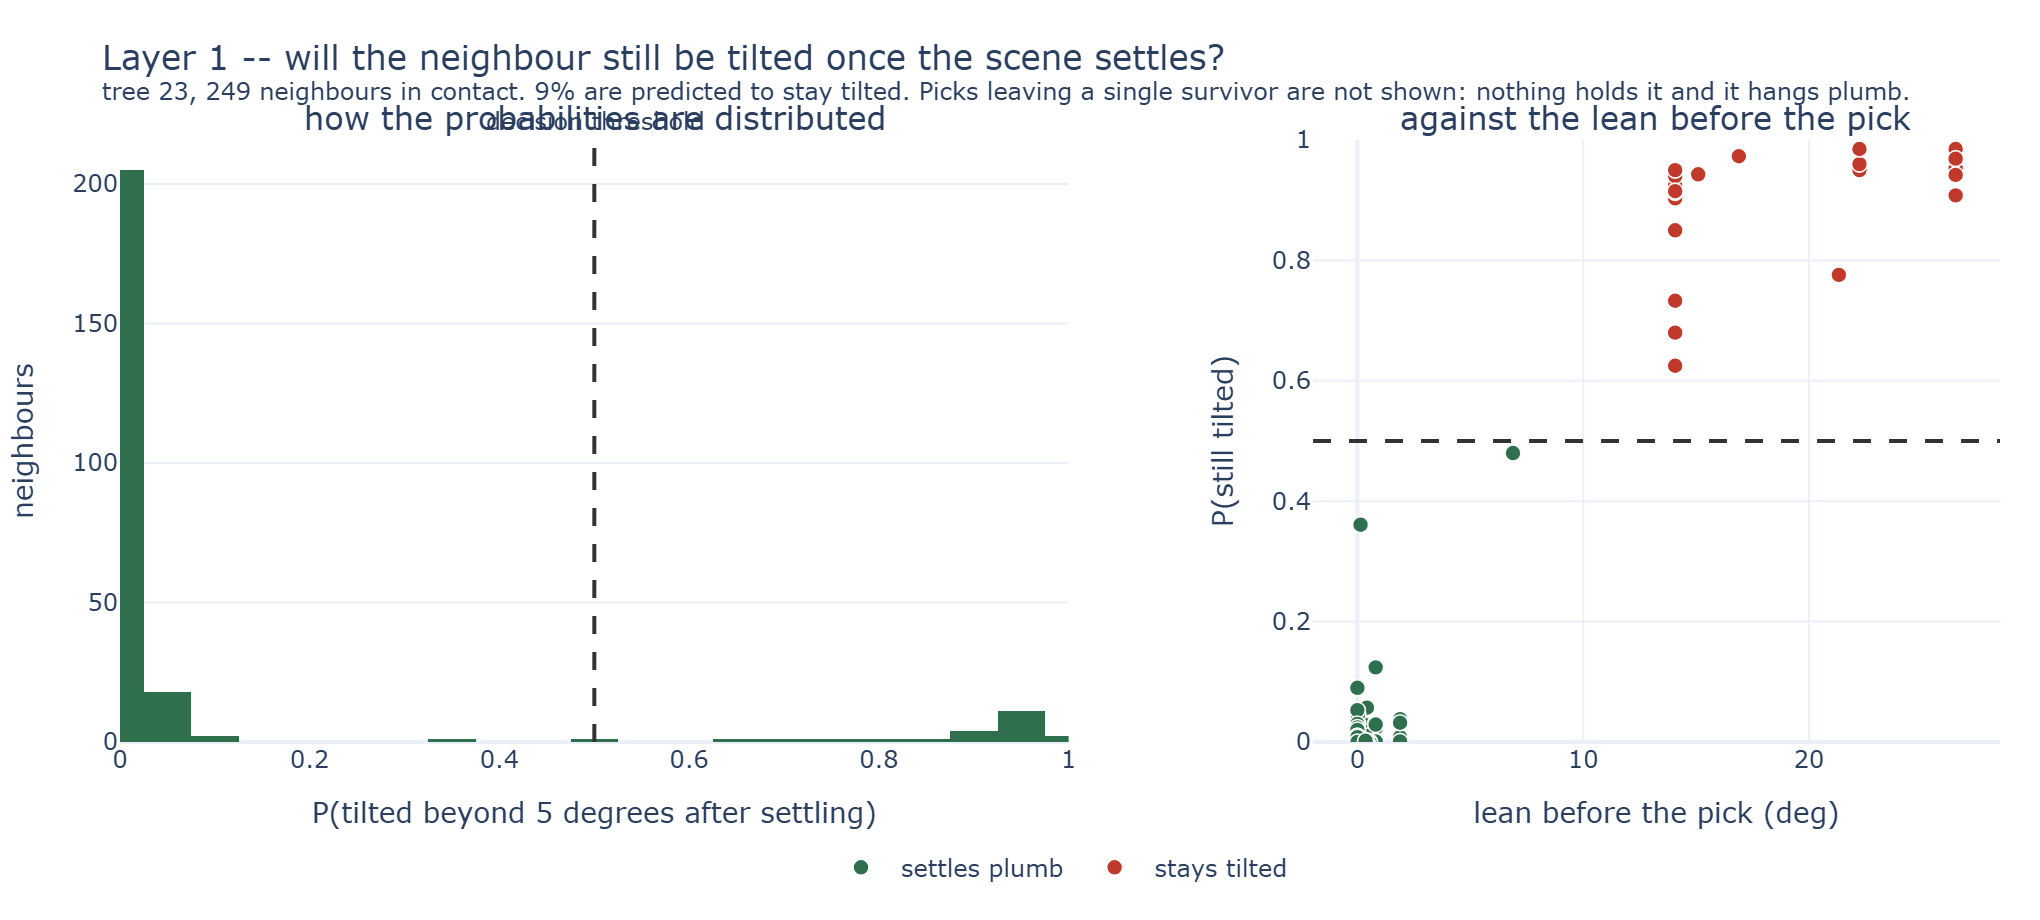

  fig5_layer1_dynamics.png + .html


Resorting to unclean kill browser.


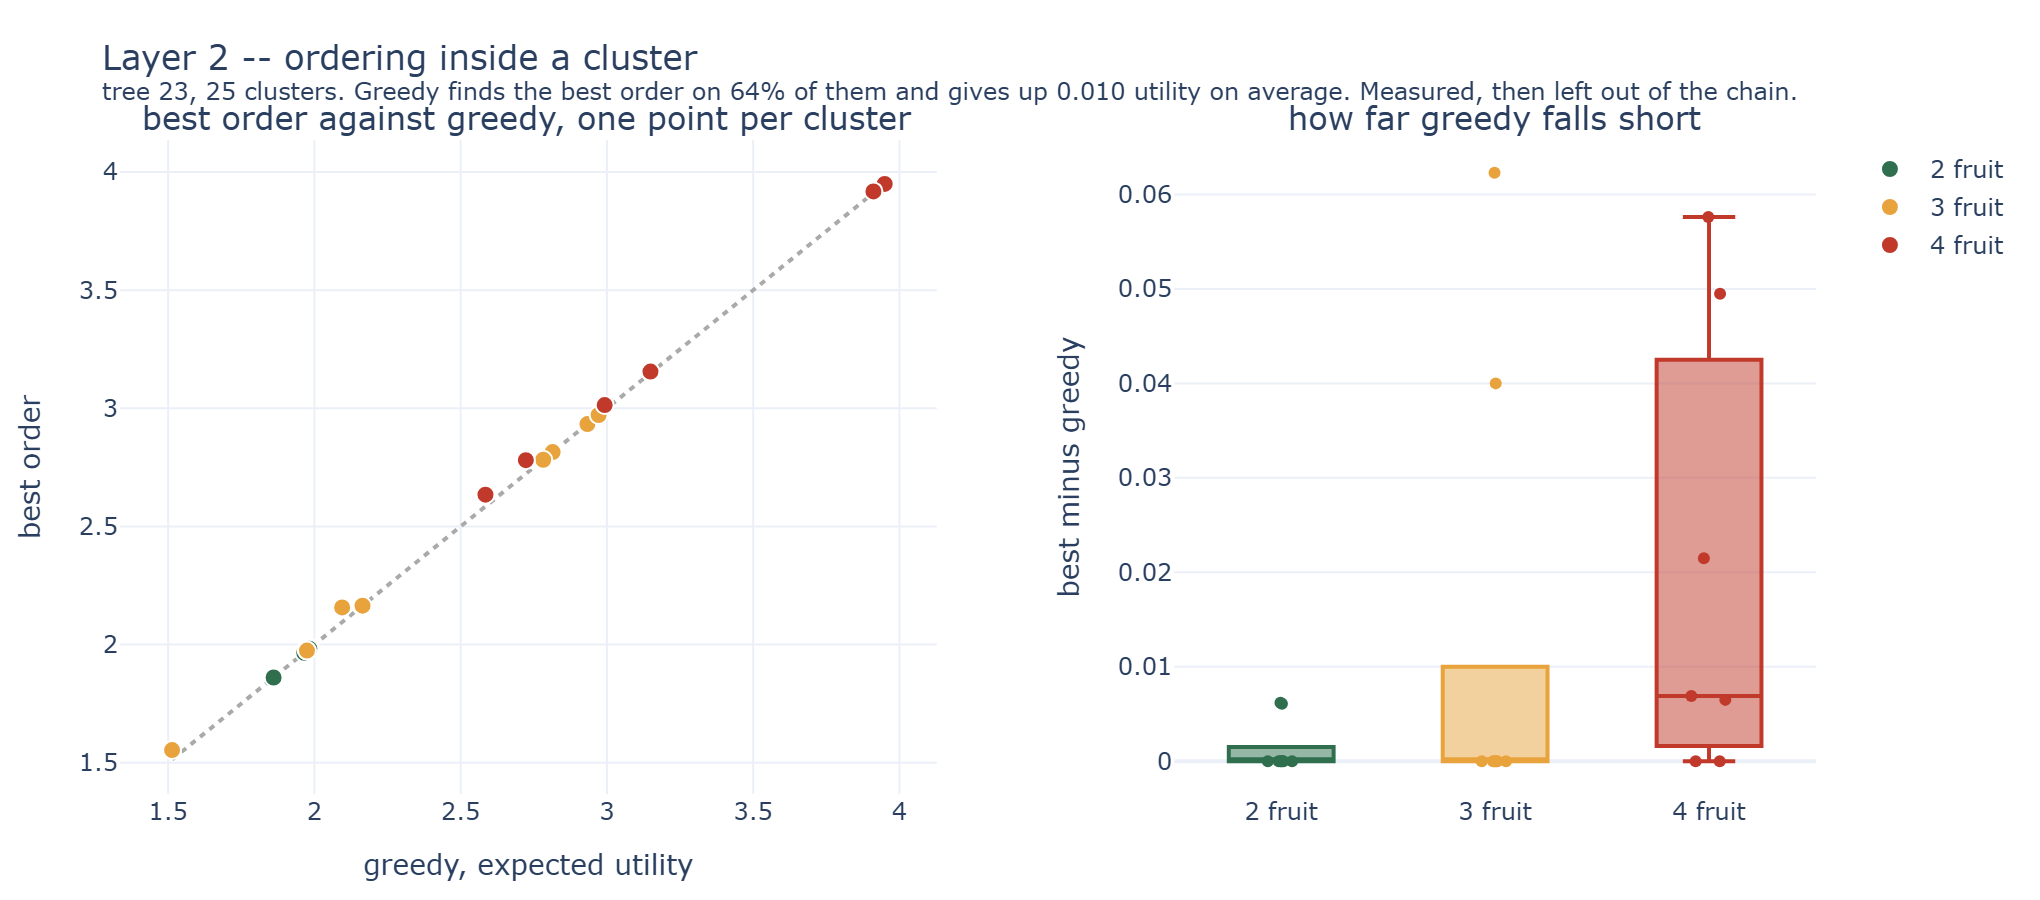

  fig6_layer2_cluster.png + .html


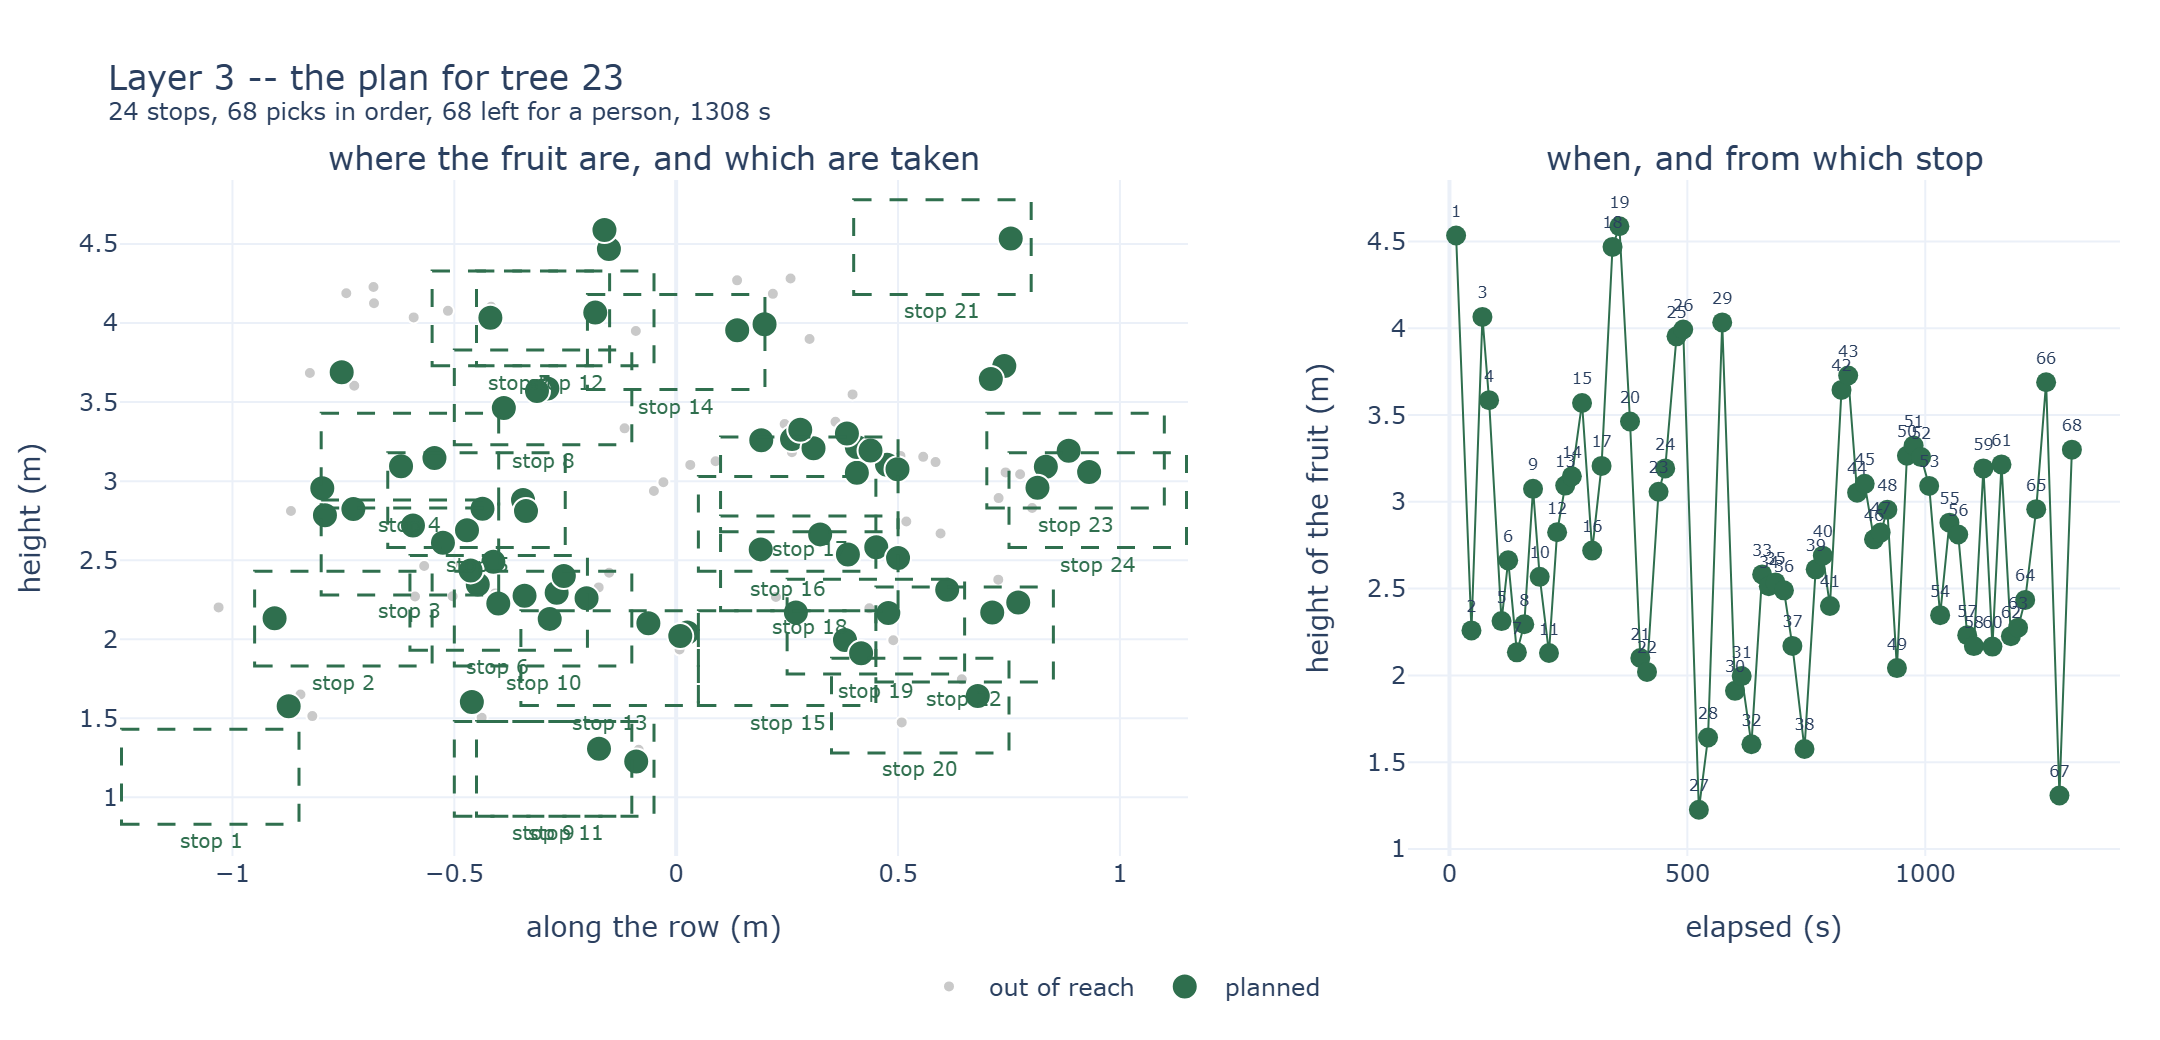

  fig7_layer3_plan.png + .html


In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

GREEN, AMBER, RED, GREY = "#2f6f4e", "#e8a33d", "#c0392b", "#c9c9c9"
PAPER = dict(template="plotly_white", margin=dict(l=60, r=20, t=70, b=50))


def save(fig, name, scale=2, show=True):
    """Write the figure, then display the PNG in the notebook.

    Not `fig.show()`: a plotly widget does not survive being written into the .ipynb, so the
    figure is gone once the kernel stops. The PNG embeds as bytes and travels with the file.
    """
    fig.write_html(REPORT/f"{name}.html", include_plotlyjs="cdn")
    out = f"{name}.html only -- kaleido missing"
    try:
        fig.write_image(REPORT/f"{name}.png", scale=scale)
        out = f"{name}.png + .html"
    except Exception as ex:
        out = f"{name}.html only -- {type(ex).__name__}; pip install -U kaleido for the png"
    if show and (REPORT/f"{name}.png").exists():
        from IPython.display import Image, display
        display(Image(filename=str(REPORT/f"{name}.png")))
    return out


# --- Layer 1 -------------------------------------------------------------------------------
# A bar per neighbour ran to two hundred rows on a full tree, which is unreadable and will not
# fit a page. The distribution is what the section actually argues -- most neighbours settle
# plumb, a minority do not -- so it is drawn as one.
if len(DYN_ROWS):
    d = DYN_ROWS
    tilted = (d.p_still_tilted >= E.DYN_THRESH)

    f5 = make_subplots(rows=1, cols=2, column_widths=[0.58, 0.42], horizontal_spacing=0.13,
                       subplot_titles=("how the probabilities are distributed",
                                       "against the lean before the pick"))
    f5.add_trace(go.Histogram(x=d.p_still_tilted, nbinsx=25, marker_color=GREEN,
                              name="all neighbours", showlegend=False,
                              hovertemplate="P %{x:.2f}<br>%{y} neighbours<extra></extra>"),
                 row=1, col=1)
    f5.add_vline(x=E.DYN_THRESH, line=dict(dash="dash", color="#333"),
                 annotation_text="decision threshold", annotation_position="top",
                 row=1, col=1)

    for m, colour, name in ((~tilted, GREEN, "settles plumb"),
                            (tilted, RED, "stays tilted")):
        if m.any():
            f5.add_trace(go.Scatter(
                x=d.lean_before[m], y=d.p_still_tilted[m], mode="markers", name=name,
                marker=dict(size=8, color=colour, line=dict(width=0.8, color="white")),
                hovertext=[f"pick {st}: {int(a)} -> {int(b)}, {int(sv)} survivors"
                           for st, a, b, sv in zip(d.step[m], d.picked[m],
                                                   d.neighbour[m], d.survivors[m])],
                hoverinfo="text+x+y"), row=1, col=2)
    f5.add_hline(y=E.DYN_THRESH, line=dict(dash="dash", color="#333"), row=1, col=2)

    f5.update_xaxes(title_text="P(tilted beyond 5 degrees after settling)", range=[0, 1],
                    row=1, col=1)
    f5.update_yaxes(title_text="neighbours", row=1, col=1)
    f5.update_xaxes(title_text="lean before the pick (deg)", row=1, col=2)
    f5.update_yaxes(title_text="P(still tilted)", range=[0, 1], row=1, col=2)
    f5.update_layout(
        title=f"Layer 1 -- will the neighbour still be tilted once the scene settles?"
              f"<br><sup>tree {DEMO}, {len(d)} neighbours in contact. "
              f"{tilted.mean()*100:.0f}% are predicted to stay tilted. Picks leaving a single "
              f"survivor are not shown: nothing holds it and it hangs plumb.</sup>",
        legend=dict(orientation="h", yanchor="top", y=-0.16, xanchor="center", x=0.5),
        width=1020, height=460, **PAPER)
    print(" ", save(f5, "fig5_layer1_dynamics"))
else:
    print("  fig5 skipped: no pick on this tree left two or more survivors in contact")


# --- Layer 2 -------------------------------------------------------------------------------
if len(CL):
    f6 = make_subplots(rows=1, cols=2, horizontal_spacing=0.14, column_widths=[0.56, 0.44],
                       subplot_titles=("best order against greedy, one point per cluster",
                                       "how far greedy falls short"))
    lo = float(min(CL.exhaustive.min(), CL.greedy.min()))
    hi = float(max(CL.exhaustive.max(), CL.greedy.max()))
    f6.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines", showlegend=False,
                            line=dict(dash="dot", color="#aaa")), row=1, col=1)
    for size, colour in ((2, GREEN), (3, AMBER), (4, RED)):
        m = CL["size"] == size
        if m.any():
            f6.add_trace(go.Scatter(
                x=CL.greedy[m], y=CL.exhaustive[m], mode="markers", name=f"{size} fruit",
                marker=dict(size=9, color=colour, line=dict(width=1, color="white")),
                text=[f"gap {g:.3f}" for g in CL.gap[m]], hoverinfo="text+x+y"), row=1, col=1)
            f6.add_trace(go.Box(y=CL.gap[m], name=f"{size} fruit", marker_color=colour,
                                boxpoints="all", jitter=0.4, pointpos=0, showlegend=False),
                         row=1, col=2)
    f6.update_xaxes(title_text="greedy, expected utility", row=1, col=1)
    f6.update_yaxes(title_text="best order", row=1, col=1)
    f6.update_yaxes(title_text="best minus greedy", row=1, col=2)
    f6.update_layout(
        title=f"Layer 2 -- ordering inside a cluster"
              f"<br><sup>tree {DEMO}, {len(CL)} clusters. Greedy finds the best order on "
              f"{(CL.gap < 1e-9).mean()*100:.0f}% of them and gives up {CL.gap.mean():.3f} "
              f"utility on average. Measured, then left out of the chain.</sup>",
        width=1020, height=450, **PAPER)
    print(" ", save(f6, "fig6_layer2_cluster"))
else:
    print("  fig6 skipped: no clusters of two to four on this tree")

# --- Layer 3 -------------------------------------------------------------------------------
g = geom
picked = list(PLAN.fruit)
reach = Cp.any(axis=0)
ispick = np.isin(g.ids, picked)

f7 = make_subplots(rows=1, cols=2, column_widths=[0.60, 0.40], horizontal_spacing=0.11,
                   subplot_titles=("where the fruit are, and which are taken",
                                   "when, and from which stop"))
for mask, colour, size, name in ((~reach, GREY, 6, "out of reach"),
                                 (reach & ~ispick, AMBER, 9, "left for a person"),
                                 (ispick, GREEN, 13, "planned")):
    if mask.any():
        f7.add_trace(go.Scatter(x=g.P[mask, 0], y=g.P[mask, 1], mode="markers", name=name,
                                marker=dict(size=size, color=colour,
                                            line=dict(width=1, color="white"))),
                     row=1, col=1)
for i, r in enumerate(STOPS, 1):
    x, mast = Pp[r]
    f7.add_shape(type="rect", x0=x-HALF_X, x1=x+HALF_X, y0=mast-LIFT/2, y1=mast+LIFT/2,
                 line=dict(color=GREEN, dash="dash", width=1.5), row=1, col=1)
    f7.add_annotation(x=x, y=mast-LIFT/2-0.10, text=f"stop {i}", showarrow=False,
                      font=dict(size=10, color=GREEN), row=1, col=1)
f7.add_trace(go.Scatter(x=PLAN.secs, y=PLAN.height, mode="markers+lines+text",
                        marker=dict(size=10, color=GREEN), line=dict(color=GREEN, width=1),
                        text=[str(i) for i in PLAN.step], textposition="top center",
                        textfont=dict(size=8), showlegend=False,
                        hovertext=[f"fruit {int(f)}, stop {int(s)}, P={p:.3f}"
                                   for f, s, p in zip(PLAN.fruit, PLAN.stop, PLAN.p_success)],
                        hoverinfo="text"), row=1, col=2)
f7.update_xaxes(title_text="along the row (m)", row=1, col=1)
f7.update_yaxes(title_text="height (m)", row=1, col=1)
f7.update_xaxes(title_text="elapsed (s)", row=1, col=2)
f7.update_yaxes(title_text="height of the fruit (m)", row=1, col=2)
f7.update_layout(
    # `S` was the old station list. Reading the count from the plan is what keeps the caption
    # honest -- an earlier version of this figure went out saying eighteen stops while drawing
    # twenty-four.
    title=f"Layer 3 -- the plan for tree {DEMO}"
          f"<br><sup>{PLAN.stop.nunique()} stops, {len(PLAN)} picks in order, "
          f"{int((st.alive & reach).sum())} left for a person, "
          f"{PLAN.secs.iloc[-1]:.0f} s</sup>",
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
    width=1080, height=520, margin=dict(l=60, r=20, t=90, b=90),
    template="plotly_white")
print(" ", save(f7, "fig7_layer3_plan"))





In [5]:
# --- Layer 4: the table, in the three forms a manuscript needs -------------------------------
p_succ = PLAN.p_success.to_numpy(float)
exp_u = PLAN.exp_utility.to_numpy(float)
secs = float(PLAN.secs.iloc[-1])
reach_n = int(Cp.any(axis=0).sum())
left = int((st.alive & Cp.any(axis=0)).sum())
between = E.TREE_SPACING/E.TRAVEL
trees_hr = 3600.0/(secs + between)

TAB = pd.DataFrame([
    ("Fruit on the tree",        f"{geom.n}",                          "synthetic canopy"),
    ("Reachable from the grid",  f"{reach_n}",                         "arm 0.20 x 0.60 m"),
    ("Planned by the robot",     f"{len(PLAN)}",                       f"{len(PLAN)/geom.n*100:.0f} percent of the tree"),
    ("Left for a person",        f"{left}",                            f"selection threshold {THRESHOLD}"),
    ("Stops",                    f"{PLAN.stop.nunique()}",             "where fruit were actually taken"),
    ("Expected premium fruit",   f"{p_succ.sum():.2f}",                "sum of P(success)"),
    ("Expected utility",         f"{exp_u.sum():.2f}",                 "grade units, not fruit"),
    ("Cost of damage",           f"{p_succ.sum() - exp_u.sum():.2f}",  "knocked neighbours and torn stems"),
    ("Time on the tree",         f"{secs:.0f} s",                      f"{secs/len(PLAN):.1f} s per attempt"),
    ("Trees per hour",           f"{trees_hr:.1f}",                    f"including {between:.0f} s between trees"),
    ("Premium fruit per hour",   f"{trees_hr*p_succ.sum():.0f}",       "this tree, extrapolated"),
    ("Measured over 30 seeds",   "238.0",                              "the figure to quote"),
], columns=["Quantity", "Value", "Note"])

print(TAB.to_string(index=False))
print("\n  The last two rows are different numbers and should not be swapped. The extrapolation")
print("  makes the arithmetic on one tree visible; the measured figure is what thirty paired")
print("  seeds over thirty held-out trees actually produced.")
print(f"\n  The pick cycle is fixed at {E.PICK_SECONDS:.0f} s and is not measured from a machine.")
print("  Halving it is worth more than every planning lever combined, so it is the number to")
print("  interrogate before any of the rest.")


def to_markdown(df):
    # pandas routes to_markdown through tabulate, which is not installed here and is not worth
    # a dependency for three columns.
    w = [max(len(str(c)), *(len(str(v)) for v in df[c])) for c in df.columns]
    head = "| " + " | ".join(str(c).ljust(n) for c, n in zip(df.columns, w)) + " |"
    rule = "|" + "|".join("-"*(n+2) for n in w) + "|"
    body = ["| " + " | ".join(str(v).ljust(n) for v, n in zip(r, w)) + " |"
            for r in df.itertuples(index=False)]
    return "\n".join([head, rule] + body)


def to_latex(df, caption, label):
    esc = lambda s: (str(s).replace("\\", r"\textbackslash{}").replace("_", r"\_")
                     .replace("%", r"\%").replace("&", r"\&").replace("#", r"\#"))
    lines = [r"\begin{table}[t]", r"\centering",
             r"\begin{tabular}{@{}llp{0.42\linewidth}@{}}", r"\toprule",
             " & ".join(esc(c) for c in df.columns) + r" \\", r"\midrule"]
    lines += [" & ".join(esc(v) for v in r) + r" \\" for r in df.itertuples(index=False)]
    lines += [r"\bottomrule", r"\end{tabular}",
              rf"\caption{{{esc(caption)}}}", rf"\label{{{label}}}", r"\end{table}"]
    return "\n".join(lines)


stem = f"layer4_utility_tree{DEMO}"
md = (f"**Table. What the plan is worth -- tree {DEMO}.** Expected values come from the outcome "
      f"model; the measured shift figure comes from `03_evaluation`.\n\n"
      + to_markdown(TAB) + "\n")
(REPORT/f"{stem}.md").write_text(md, encoding="utf-8")
(REPORT/f"{stem}.tex").write_text(
    to_latex(TAB, f"What the plan is worth, tree {DEMO}.", "tab:utility"), encoding="utf-8")
TAB.to_csv(REPORT/f"{stem}.csv", index=False)

print("\n\nmarkdown, ready to paste\n")
print(md)

print(f"\nwritten to {REPORT}\n")
for f in sorted(REPORT.iterdir()):
    print(f"  {f.name:<40} {f.stat().st_size/1024:8.1f} KB")

png = [f for f in REPORT.glob("*.png")]
if not png:
    print("\n  No png yet: plotly needs kaleido to write a still image.")
    print("      pip install -U kaleido")
    print("  The html files are complete and can be screenshotted in the meantime.")




               Quantity  Value                              Note
      Fruit on the tree    120                  synthetic canopy
Reachable from the grid     68                 arm 0.20 x 0.60 m
   Planned by the robot     68            57 percent of the tree
      Left for a person     68           selection threshold 0.0
                  Stops     24   where fruit were actually taken
 Expected premium fruit  56.10                 sum of P(success)
       Expected utility  52.17            grade units, not fruit
         Cost of damage   3.94 knocked neighbours and torn stems
       Time on the tree 1308 s                19.2 s per attempt
         Trees per hour    2.7       including 3 s between trees
 Premium fruit per hour    154           this tree, extrapolated
 Measured over 30 seeds  238.0               the figure to quote

  The last two rows are different numbers and should not be swapped. The extrapolation
  makes the arithmetic on one tree visible; the measured figure is 

## 3. Does the plan survive the physics?

The plan above is the model's account of what will happen. `04_fidelity` ran the same tree
against MuJoCo and wrote down what did. Reading the two together is the only way to see whether
a particular optimistic probability was optimistic about a particular fruit.


In [6]:
ev = RUNS/"fidelity"/"logs"/f"events_{DEMO}_policy.jsonl"
if not ev.exists():
    print(f"{ev} not found -- run 04_fidelity, or point DEMO at a tree it covered")
    REAL = None
else:
    REAL = pd.DataFrame([json.loads(l) for l in ev.read_text().splitlines() if l.strip()])
    print(f"{len(REAL)} picks replayed against the physics\n")

    keep = [c for c in ("fruit", "p_success", "cls", "code", "mj_lean_deg") if c in REAL]
    M = PLAN[["step", "stop", "fruit", "p_success"]].merge(
        REAL[keep], on="fruit", how="outer", suffixes=("_planned", "_physics"))
    print(M.to_string(index=False))

    hit = REAL.cls.isin(["SUCCESS", "NEIGHBOR_KNOCKED"])
    print(f"\n  predicted mean {REAL.p_success.mean():.3f}   realised {hit.mean():.3f}   "
          f"gap {hit.mean() - REAL.p_success.mean():+.3f}")
    print(f"  outcomes: " + ", ".join(f"{k} {v}" for k, v in REAL.cls.value_counts().items()))
    print("\n  One tree is one tree. The gap that matters is the one over 829 picks in 04;")
    print("  this is here so a single case can be inspected rather than trusted.")



38 picks replayed against the physics

 step  stop  fruit  p_success_planned  p_success_physics              cls             code  mj_lean_deg
   53    24      1             0.5271                NaN              NaN              NaN          NaN
   54    10      3             0.3322                NaN              NaN              NaN          NaN
   32     9      4             0.9694                NaN              NaN              NaN          NaN
   60    19      7             0.3524                NaN              NaN              NaN          NaN
    3     8      8             0.9951             0.9951     GRASP_FAILED     GRASP_FAILED        0.000
   44    16     10             0.8771                NaN              NaN              NaN          NaN
   45    17     12             0.9732                NaN              NaN              NaN          NaN
   28    20     14             0.9759                NaN              NaN              NaN          NaN
   65    24     16       

## 4. The checks

Not a full test suite — the ones that have each caught something real. A silent version of any
of these would have cost hours, and two of them did before they existed.


In [7]:
CHECKS = []


def check(name, fn, why):
    try:
        CHECKS.append((True, name, fn(), why))
    except Exception as ex:
        CHECKS.append((False, name, f"{type(ex).__name__}: {ex}", why))


def _scenes():
    rig, servo = A.make_rig()
    n = [rig.m.nbody]
    for nm in ("harvest_scene_az.xml", "harvest_scene_stem.xml", "stalk_scene.xml"):
        n.append(mujoco.MjModel.from_xml_path(A._scene(nm)).nbody)
    return f"{n} bodies, loaded from cwd {Path.cwd().name}"


def _determinism():
    out = []
    for _ in range(2):
        g, _, _ = E.tree_cache(DEMO, HALF_X, LIFT)
        out.append(E.TreeState(g).utilities().copy())
    assert np.array_equal(out[0], out[1]), "two calls disagreed"
    return "identical utilities on repeat"


def _scaling():
    names = list(E.FEATS) + [f"p_{c}" for c in E.CLASSES] + ["move_secs", "rate"]
    k = names.index("move_secs")
    assert abs(PL.FMU[k] - 385.324) < 8, f"move_secs {PL.FMU[k]:.1f}, training said 385.3"
    return f"move_secs {PL.FMU[k]:.1f} / {PL.FSD[k]:.1f}, matching training"


def _pose():
    assert "lean_deg" in E.T.columns, "canopy has no measured pose"
    n = np.linalg.norm(E.T[["sax_x", "sax_y", "sax_z"]].to_numpy(float), axis=1)
    assert np.abs(n - 1).max() < 1e-6, "stalk axis is not a unit vector"
    return f"{len(E.T):,} fruit, axis unit to {np.abs(n-1).max():.1e}"


def _plan():
    assert len(PLAN) >= 3, "the policy stopped almost immediately"
    assert PLAN.fruit.nunique() == len(PLAN), "a fruit was planned twice"
    assert S["in_plan"] == S["robot_reach"], (
        f"{S['robot_reach'] - S['in_plan']} reachable fruit are not in the plan; the sweep "
        "stage is supposed to leave none")
    return (f"{len(PLAN)} picks over {PLAN.stop.nunique()} stops, "
            f"all {S['robot_reach']} reachable fruit planned")


def _dataset():
    D = pd.read_csv(DATA/"picks.csv", usecols=["apple_id", "aperture_ratio"])
    per = D.groupby("apple_id").size()
    assert (per == 4).mean() > 0.99, "not four apertures per fruit"
    return f"{D.apple_id.nunique():,} fruit, four apertures each"


def _one_copy():
    import inspect
    src = inspect.getsource(PL)
    assert "def plan_tree" in src and "def sweep_remaining" in src
    return f"planning logic in one module, {len(src.splitlines())} lines"


check("physics scenes load", _scenes,
      "from_xml_path resolves against the working directory; this failed silently once")
check("environment is deterministic", _determinism,
      "every paired comparison assumes a repeat gives the same answer")
check("policy scaling matches training", _scaling,
      "a mismatch collapses the policy to an immediate stop and looks like a weak model")
check("canopy carries a measured pose", _pose,
      "the planner used to fabricate this from a lookup table")
check("the plan is well formed", _plan,
      "an empty plan used to surface three cells later as a missing column")
check("dataset is counterfactual", _dataset,
      "the four aperture rows have to move together or the comparison is observational")
check("planning logic has one home", _one_copy,
      "three notebooks each had their own copy and the copies drifted apart")

print(f"{sum(ok for ok, *_ in CHECKS)}/{len(CHECKS)} passed\n")
for ok, name, detail, why in CHECKS:
    print(f"  {'ok  ' if ok else 'FAIL'} {name}")
    print(f"       {detail}")
    print(f"       why: {why}")
if not all(ok for ok, *_ in CHECKS):
    raise RuntimeError("a check failed -- the numbers above it are not trustworthy")



7/7 passed

  ok   physics scenes load
       [14, 14, 14, 7] bodies, loaded from cwd git
       why: from_xml_path resolves against the working directory; this failed silently once
  ok   environment is deterministic
       identical utilities on repeat
       why: every paired comparison assumes a repeat gives the same answer
  ok   policy scaling matches training
       move_secs 385.3 / 485.5, matching training
       why: a mismatch collapses the policy to an immediate stop and looks like a weak model
  ok   canopy carries a measured pose
       6,000 fruit, axis unit to 3.3e-16
       why: the planner used to fabricate this from a lookup table
  ok   the plan is well formed
       68 picks over 24 stops, all 68 reachable fruit planned
       why: an empty plan used to surface three cells later as a missing column
  ok   dataset is counterfactual
       8,133 fruit, four apertures each
       why: the four aperture rows have to move together or the comparison is observational
  ok

## 5. Images for the report

Four figures, written as PNG. The first two are the physics itself, rendered by MuJoCo rather
than drawn — a reader can see the gripper, the stalk and the leaves rather than take their
description on trust. The other two are the plan and the calibration.


In [8]:
def render_scene(units, aperture, dim_true, cam=None, w=900, h=700):
    '''A rendered image of the scene the generator builds for one pick.'''
    m = mujoco.MjModel.from_xml_string(G.scene_for(units, aperture, dim_true=dim_true))
    d = mujoco.MjData(m)
    G.settle_scene(m, d)
    mujoco.mj_forward(m, d)
    r = mujoco.Renderer(m, height=h, width=w)
    c = mujoco.MjvCamera()
    mujoco.mjv_defaultCamera(c)
    c.distance, c.azimuth, c.elevation = (cam or (0.32, 135.0, -12.0))
    c.lookat[:] = d.body("fruit").xpos
    r.update_scene(d, camera=c)
    return r.render()


T = E.T
row = T[(T.tree == DEMO) & T.vis_any].iloc[0]
sub = T[(T.tree == DEMO) & (T.fruit_id != row.fruit_id)]
c0 = np.array([row.x, row.y, row.z], float)
dd = np.linalg.norm(sub[["x", "y", "z"]].to_numpy(float) - c0, axis=1)
near = sub.iloc[np.argsort(dd)[:2]]
R = np.array([[1., 0, 0], [0, 0, 1], [0, 1, 0]])
units = [dict(name="A", abs_pt=np.zeros(3),
              sdir=R @ np.array([row.sdir_x, row.sdir_y, row.sdir_z], float),
              dim=float(row.dim), apple_id=int(row.fruit_id))]
for i, (_, o) in enumerate(near.iterrows()):
    units.append(dict(name=f"N{i}", abs_pt=R @ (np.array([o.x, o.y, o.z], float) - c0),
                      sdir=R @ np.array([o.sdir_x, o.sdir_y, o.sdir_z], float),
                      dim=float(o.dim), apple_id=int(o.fruit_id)))

try:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, (az, el, ttl) in zip(axes, [(135, -12, "three quarter"),
                                        (90, 0, "side"), (180, -35, "from below")]):
        ax.imshow(render_scene(units, G.aperture_from(1.0, float(row.dim)), float(row.dim),
                               cam=(0.32, az, el)))
        ax.set_title(ttl, fontsize=9); ax.axis("off"); ax.grid(False)
    fig.suptitle(f"The scene one pick is decided in — tree {DEMO}, fruit {int(row.fruit_id)}, "
                 f"{len(units)-1} neighbours", y=1.02)
    fig.savefig(REPORT/"fig1_scene.png")
    from IPython.display import display as _d
    _d(fig)
    plt.close(fig)
    print(f"fig1_scene.png -- the gripper, the stalk chain and the leaves, as MuJoCo has them")
except Exception as ex:
    print(f"scene render unavailable ({type(ex).__name__}: {ex})")
    print("  MuJoCo needs a GL context; on a headless machine set MUJOCO_GL=osmesa")




<Figure size 1690x468 with 3 Axes>

fig1_scene.png -- the gripper, the stalk chain and the leaves, as MuJoCo has them


fig2_plan.html -- open it and turn the canopy; dashed boxes are the arm reach


Resorting to unclean kill browser.


fig2_plan.png  -- still image for the report


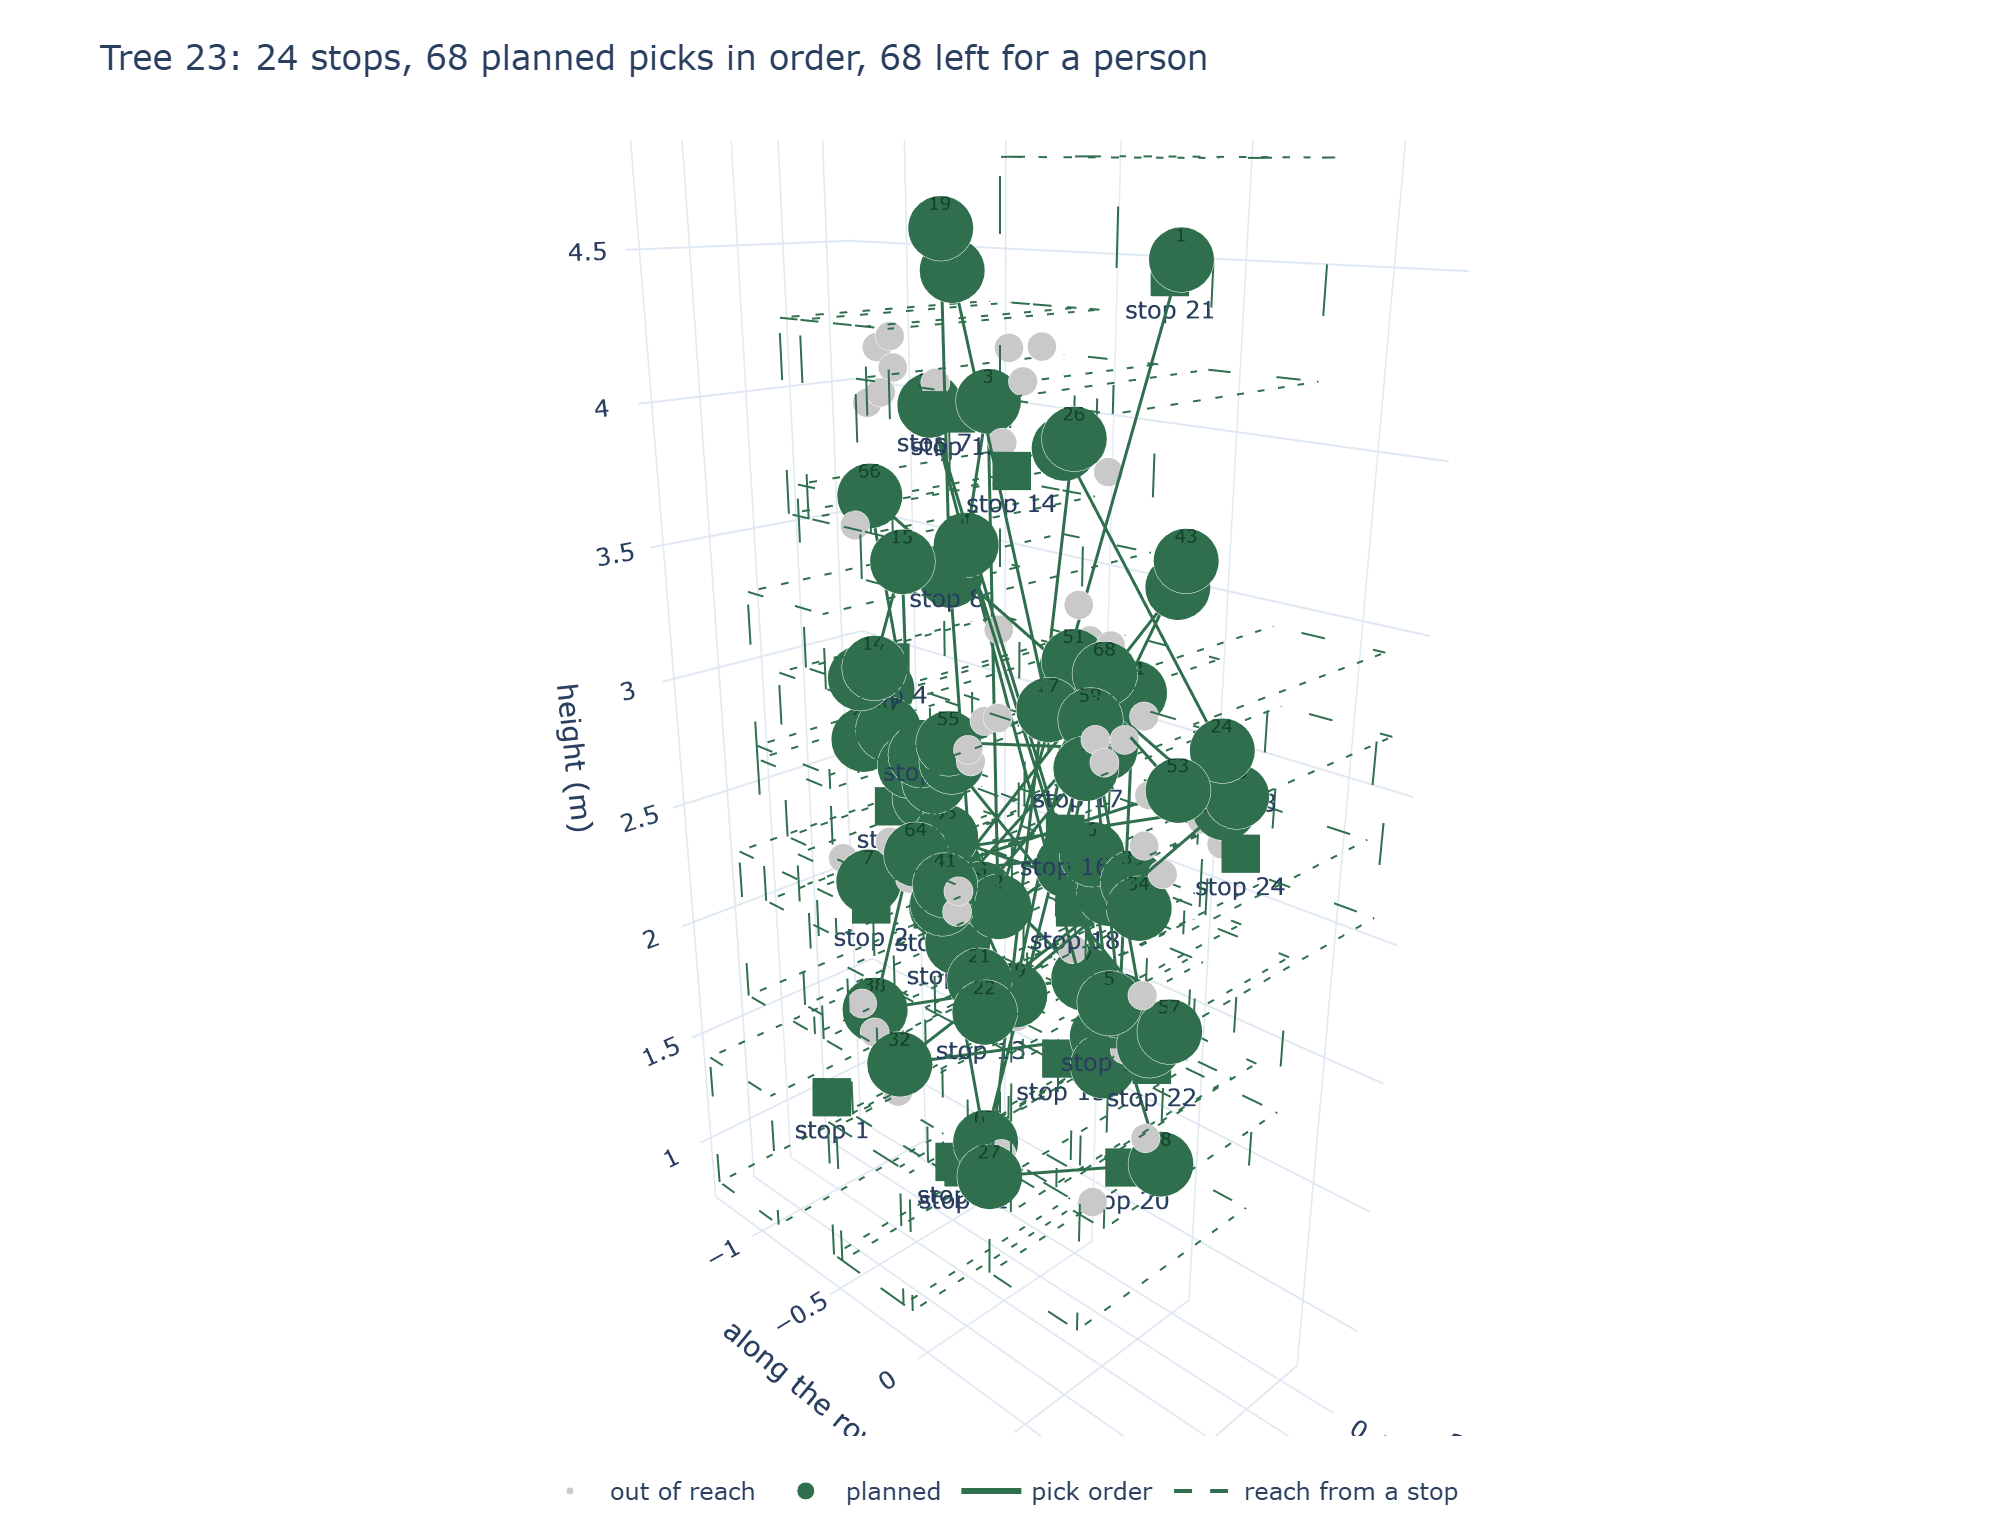

In [9]:
# --- Figure 2: the tree in three dimensions ------------------------------------------------
# Plotly rather than a static plot. The canopy is a volume, the stops are boxes inside it, and
# any fixed viewpoint hides whichever fruit sits behind another. The html keeps the rotation;
# the png is for the document and needs kaleido.
import plotly.graph_objects as go


def show_png(name):
    """Display a saved PNG in the notebook output.

    Not `fig.show()`: a plotly widget does not survive being written into the .ipynb, so the
    figure is gone the moment the kernel stops. The PNG embeds as bytes and travels with the
    file. Defined here rather than in a shared cell so this cell runs on its own.
    """
    p = REPORT/f"{name}.png"
    if p.exists():
        from IPython.display import Image, display
        display(Image(filename=str(p)))
    else:
        print(f"  {p.name} not written -- pip install -U kaleido")


g = geom
picked = list(PLAN.fruit)
order = {int(f): i for i, f in enumerate(picked, 1)}
reach = Cp.any(axis=0)
is_picked = np.isin(g.ids, picked)

GREEN, AMBER, GREY = "#2f6f4e", "#e8a33d", "#c9c9c9"
fig = go.Figure()

for mask, colour, size, name in ((~reach, GREY, 4, "out of reach"),
                                 (reach & ~is_picked, AMBER, 6, "left for a person"),
                                 (is_picked, GREEN, 9, "planned")):
    if not mask.any():
        continue
    txt = [f"fruit {int(f)}<br>height {h:.2f} m"
           + (f"<br>pick #{order[int(f)]}" if int(f) in order else "")
           for f, h in zip(g.ids[mask], g.P[mask, 1])]
    fig.add_trace(go.Scatter3d(
        x=g.P[mask, 0], y=g.P[mask, 2], z=g.P[mask, 1], mode="markers", name=name,
        marker=dict(size=size, color=colour, line=dict(width=0.5, color="white")),
        text=txt, hoverinfo="text"))

# the order the robot works in, as a path through the fruit it takes
idx = [int(np.where(g.ids == f)[0][0]) for f in picked]
fig.add_trace(go.Scatter3d(
    x=g.P[idx, 0], y=g.P[idx, 2], z=g.P[idx, 1], mode="lines+text",
    line=dict(color=GREEN, width=3), name="pick order",
    text=[str(i) for i in range(1, len(idx)+1)], textposition="top center",
    textfont=dict(size=9, color="#14432b")))


def reach_box(cx, cy, cz, hx, hy, hz=0.45):
    # twelve edges of the volume the arm sweeps from one stop
    xs, ys, zs = [cx-hx, cx+hx], [cz-hz, cz+hz], [cy-hy, cy+hy]
    pts = [(x, y, z) for x in xs for y in ys for z in zs]
    X, Y, Z = [], [], []
    for a in range(8):
        for b in range(a+1, 8):
            if sum(pts[a][k] != pts[b][k] for k in range(3)) == 1:
                X += [pts[a][0], pts[b][0], None]
                Y += [pts[a][1], pts[b][1], None]
                Z += [pts[a][2], pts[b][2], None]
    return X, Y, Z


depth = float(g.P[:, 2].mean())
for i, r in enumerate(STOPS, 1):
    x, mast = Pp[r]
    X, Y, Z = reach_box(x, mast, depth, HALF_X, LIFT/2)
    fig.add_trace(go.Scatter3d(x=X, y=Y, z=Z, mode="lines",
                               line=dict(color=GREEN, width=2, dash="dash"),
                               name="reach from a stop", showlegend=(i == 1),
                               hoverinfo="skip"))
    fig.add_trace(go.Scatter3d(x=[x], y=[depth], z=[mast], mode="markers+text",
                               marker=dict(size=6, color=GREEN, symbol="square"),
                               text=[f"stop {i}"], textposition="bottom center",
                               showlegend=False, hoverinfo="skip"))

# The stop count is read from the plan rather than written into the string: an earlier version
# said "three stops" long after the configuration had moved to twenty-plus, and the caption
# went out in a report that way.
fig.update_layout(
    title=f"Tree {DEMO}: {len(STOPS)} stops, {len(PLAN)} planned picks in order, "
          f"{int((st.alive & reach).sum())} left for a person",
    scene=dict(xaxis_title="along the row (m)", yaxis_title="into the canopy (m)",
               zaxis_title="height (m)", aspectmode="data",
               camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9))),
    legend=dict(orientation="h", yanchor="top", y=-0.02, xanchor="center", x=0.5),
    margin=dict(l=0, r=0, t=70, b=40), width=1000, height=760, template="plotly_white")

fig.write_html(REPORT/"fig2_plan.html", include_plotlyjs="cdn")
print("fig2_plan.html -- open it and turn the canopy; dashed boxes are the arm reach")
try:
    fig.write_image(REPORT/"fig2_plan.png", scale=2)
    print("fig2_plan.png  -- still image for the report")
except Exception as ex:
    print(f"  png export needs kaleido ({type(ex).__name__}): pip install -U kaleido")
show_png("fig2_plan")

fig3_predicted_vs_realised -- one tree; 04 measures the same gap over 829 picks


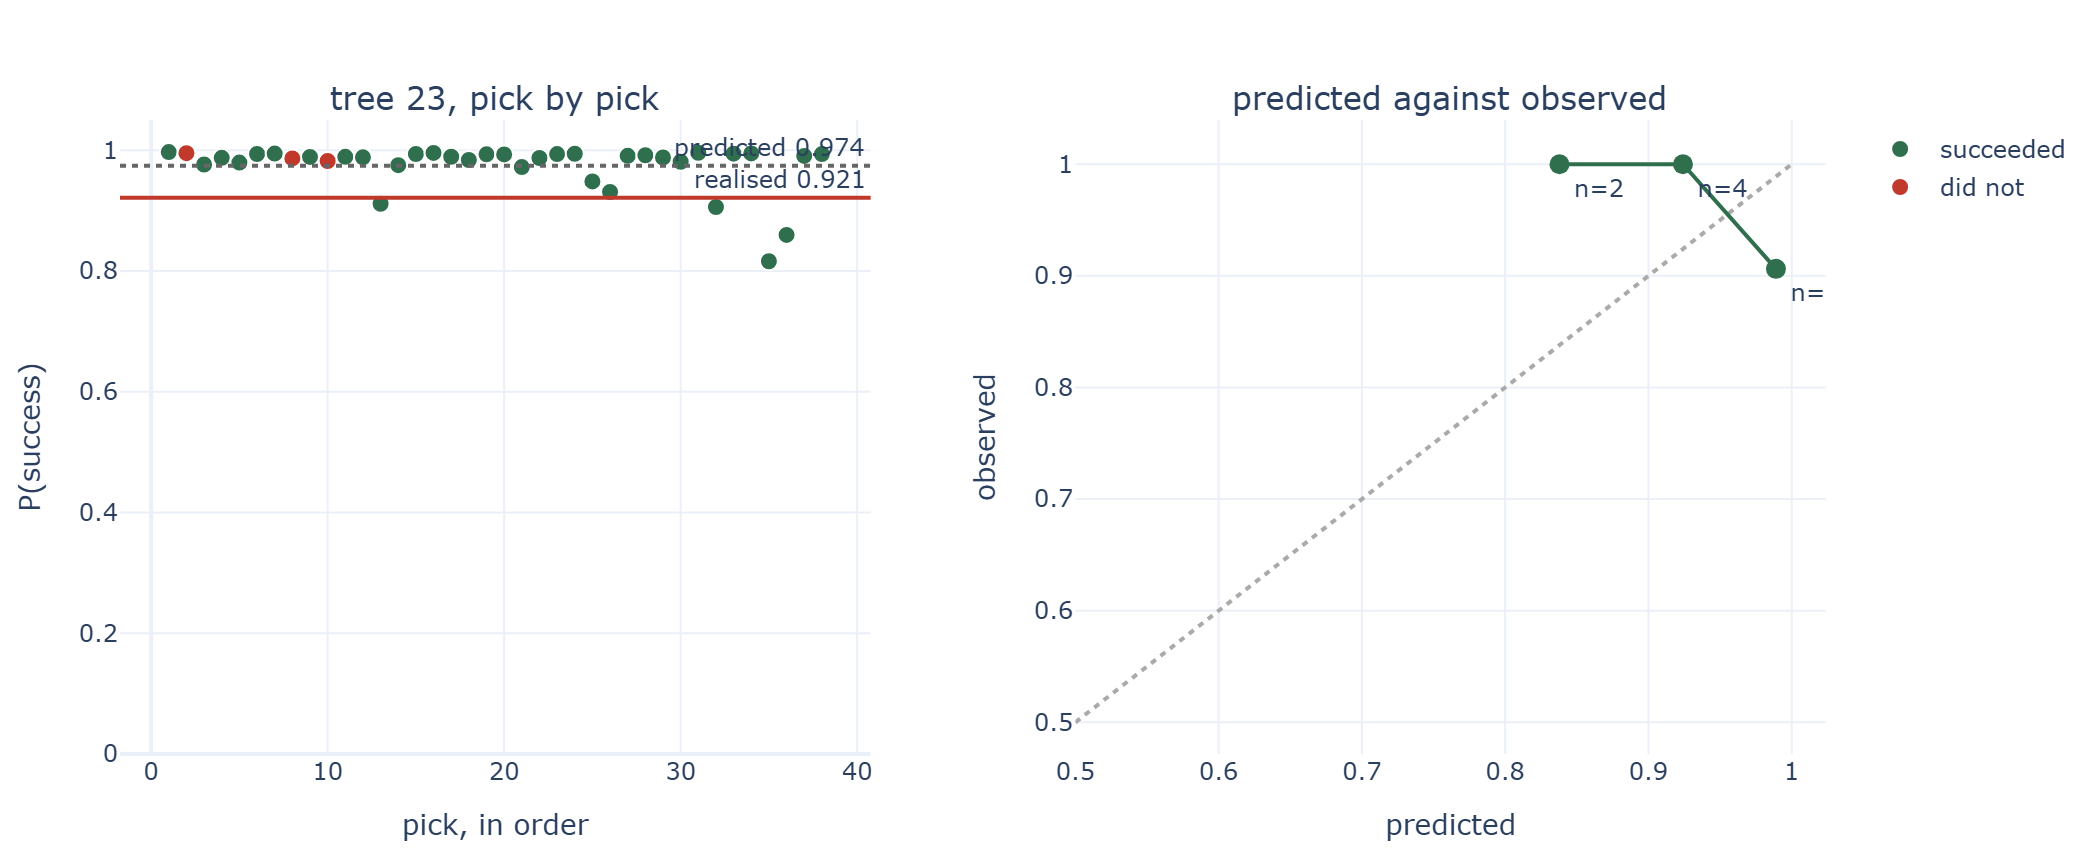

In [10]:
# --- Figure 3: what the model said, against what the physics did ----------------------------
if REAL is None:
    print("fig3 skipped: no physics replay for this tree")
else:
    from plotly.subplots import make_subplots
    ok = REAL.cls.isin(["SUCCESS", "NEIGHBOR_KNOCKED"])
    fig3 = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
                         subplot_titles=(f"tree {DEMO}, pick by pick",
                                         "predicted against observed"))
    for m, colour, nm in ((ok, GREEN, "succeeded"), (~ok, "#c0392b", "did not")):
        if m.any():
            fig3.add_trace(go.Scatter(
                x=np.where(m)[0] + 1, y=REAL.p_success[m], mode="markers", name=nm,
                marker=dict(size=9, color=colour, line=dict(width=1, color="white")),
                text=[f"fruit {int(f)}<br>{c}" for f, c in zip(REAL.fruit[m], REAL.cls[m])],
                hoverinfo="text+y"), row=1, col=1)
    fig3.add_hline(y=float(REAL.p_success.mean()), line=dict(dash="dot", color="#666"),
                   annotation_text=f"predicted {REAL.p_success.mean():.3f}", row=1, col=1)
    fig3.add_hline(y=float(ok.mean()), line=dict(color="#c0392b"),
                   annotation_text=f"realised {ok.mean():.3f}", row=1, col=1)

    band = pd.cut(REAL.p_success, [0, .8, .9, .95, 1.0])
    t = (REAL.assign(hit=ok, band=band).groupby("band", observed=True)
         .agg(predicted=("p_success", "mean"), observed=("hit", "mean"), n=("hit", "size")))
    fig3.add_trace(go.Scatter(x=[0.5, 1], y=[0.5, 1], mode="lines", showlegend=False,
                              line=dict(dash="dot", color="#aaa")), row=1, col=2)
    fig3.add_trace(go.Scatter(x=t.predicted, y=t.observed, mode="markers+lines+text",
                              marker=dict(size=10, color=GREEN), line=dict(color=GREEN),
                              text=[f"n={int(n)}" for n in t.n], textposition="bottom right",
                              showlegend=False), row=1, col=2)
    fig3.update_xaxes(title_text="pick, in order", row=1, col=1)
    fig3.update_yaxes(title_text="P(success)", range=[0, 1.05], row=1, col=1)
    fig3.update_xaxes(title_text="predicted", row=1, col=2)
    fig3.update_yaxes(title_text="observed", row=1, col=2)
    fig3.update_layout(template="plotly_white", width=1050, height=430,
                       margin=dict(l=60, r=20, t=60, b=50))
    fig3.write_html(REPORT/"fig3_predicted_vs_realised.html", include_plotlyjs="cdn")
    try:
        fig3.write_image(REPORT/"fig3_predicted_vs_realised.png", scale=2)
    except Exception:
        pass
    print("fig3_predicted_vs_realised -- one tree; 04 measures the same gap over 829 picks")
    show_png("fig3_predicted_vs_realised")



In [11]:
# --- Figure 4: the canopy correction ---------------------------------------------------------
def tilt(df):
    v = df[["sdir_x", "sdir_y", "sdir_z"]].to_numpy(float)
    v = v/np.linalg.norm(v, axis=1, keepdims=True)
    return np.degrees(np.arccos(np.clip(np.abs(v[:, 1]), 0, 1)))


series, missing = [], []
for label, name, colour in (("uniform draw", "trees_uniform_stalk.csv", "#c0392b"),
                            ("resampled from detections", "trees_resampled_stalk.csv", GREEN)):
    p = DATA/name
    if p.exists():
        series.append((label, tilt(pd.read_csv(p)), colour))
    else:
        missing.append(name)

if series:
    fig4 = go.Figure()
    for label, v, colour in series:
        fig4.add_trace(go.Histogram(x=v, name=f"{label} (median {np.median(v):.1f} deg)",
                                    marker_color=colour, opacity=0.55,
                                    histnorm="probability",
                                    xbins=dict(start=0, end=90, size=2)))
    fig4.add_vline(x=27.0, line=dict(dash="dash", color="#333"),
                   annotation_text="detections, median 27.0 deg")
    fig4.update_layout(
        barmode="overlay", template="plotly_white",
        title="The canopy correction: stalk direction was never read from the detections",
        xaxis_title="stalk tilt from vertical (deg)", yaxis_title="share of fruit",
        legend=dict(orientation="h", yanchor="bottom", y=1.02),
        width=900, height=440, margin=dict(l=60, r=20, t=80, b=50))
    fig4.write_html(REPORT/"fig4_canopy.html", include_plotlyjs="cdn")
    try:
        fig4.write_image(REPORT/"fig4_canopy.png", scale=2)
    except Exception:
        pass
    print("fig4_canopy -- red is the defect, green the fix")
    show_png("fig4_canopy")
if missing:
    print(f"  not drawn, missing: {', '.join(missing)}")

print(f"\nwritten to {REPORT}\n")
for f in sorted(REPORT.iterdir()):
    print(f"  {f.name:<38} {f.stat().st_size/1024:8.1f} KB")



  not drawn, missing: trees_uniform_stalk.csv, trees_resampled_stalk.csv

written to c:\aipick\git\runs\report

  .gitkeep                                    0.0 KB
  fig1_scene.png                            145.7 KB
  fig2_plan.html                             69.4 KB
  fig2_plan.png                             432.3 KB
  fig3_predicted_vs_realised.html            11.5 KB
  fig3_predicted_vs_realised.png            135.4 KB
  fig5_layer1_dynamics.html                  28.9 KB
  fig5_layer1_dynamics.png                  158.5 KB
  fig6_layer2_cluster.html                   11.1 KB
  fig6_layer2_cluster.png                   152.2 KB
  fig7_layer3_plan.html                      23.6 KB
  fig7_layer3_plan.png                      332.4 KB
  layer1_dynamics_tree23.csv                  8.5 KB
  layer2_clusters_tree23.csv                  0.9 KB
  layer4_utility_tree23.csv                   0.6 KB
  layer4_utility_tree23.md                    1.2 KB
  layer4_utility_tree23.tex             

### Using these

`fig1` and `fig2` carry the report on their own: one shows what a pick is, the other shows what
the system produces for a tree. `fig3` and `fig4` belong next to the fidelity and data sections
respectively.

The animation is the next piece of work and is not here. `runs/fidelity/logs/` holds a pose
stream for this tree at four frames a second, which is what it will be built from.
